### Determinar área de estudio

In [114]:
import geopandas as gpd
from shapely.geometry import Polygon, LineString, box
from shapely.ops import polygonize, unary_union

In [25]:
target_crs = "EPSG:4326"
available_fishing_area = gpd.read_file("./data/available_SWA_fishing_area.geojson")
available_fishing_area = available_fishing_area.to_crs(target_crs)

eez = gpd.read_file("./resources/Marine_Regions/World_EEZ_v12/eez_v12.shp")
eez = eez.to_crs(target_crs)
eez_fk = eez[eez["GEONAME"].str.contains("Falkland", case=False, na=False)]
p_fk_north=eez_fk.total_bounds[3]

VMEs = gpd.read_file("../../ARVI-IEO/IEO/RECURSOS/VMEs_ATSW/Categoria_VMEs/Areas_Categoria_VMEs.shp")
VME1 = VMEs[(VMEs["ID_area"] == 3) & (VMEs["Label"] == 1)]
VME1 = VME1.to_crs(target_crs)


In [ ]:
west_geom = unary_union(available_fishing_area.geometry)
east_geom = unary_union(VME1.geometry)

# Use polygon boundaries if polygons
west_boundary = west_geom.boundary
east_boundary = east_geom.boundary

# -----------------------------
# Latitude limits
# -----------------------------
south_lat = p_fk_north
north_lat = -40
# -----------------------------------
# Get overall longitude extent
# (large enough to cross both boundaries)
# -----------------------------------
minx = min(west_geom.bounds[0], east_geom.bounds[0]) - 10
maxx = max(west_geom.bounds[2], east_geom.bounds[2]) + 10

# -----------------------------------
# Create horizontal latitude lines
# -----------------------------------
south_line = LineString([
    (minx, south_lat),
    (maxx, south_lat)
])

north_line = LineString([
    (minx, north_lat),
    (maxx, north_lat)
])

# -----------------------------------
# Merge all lines together
# -----------------------------------
all_lines = unary_union([
    west_boundary,
    east_boundary,
    south_line,
    north_line
])



# -----------------------------------
# Polygonize closed regions
# -----------------------------------
polygons = list(polygonize(all_lines))

# -----------------------------------
# Convert to GeoDataFrame
# -----------------------------------
gdf_polys = gpd.GeoDataFrame(
    geometry=polygons,
    crs=target_crs
)

# -----------------------------------
# OPTIONAL:
# Keep only polygons between the latitudes
# -----------------------------------
lat_box = Polygon([
    (minx, south_lat),
    (maxx, south_lat),
    (maxx, north_lat),
    (minx, north_lat)
])

gdf_polys = gdf_polys[gdf_polys.intersects(lat_box)]




Bounding box: [-61.0, -47.375, -60.0, -44.875]


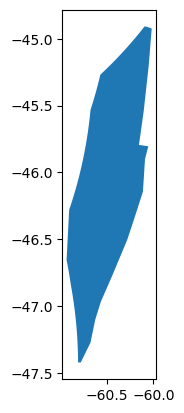

In [ ]:
study_area = gdf_polys.iloc[[1]]

study_area_m = study_area.to_crs("EPSG:3857")

cleaned = study_area_m.buffer(-2000).buffer(2000)
# Access polygons
poly = cleaned.iloc[0].geoms[0]

# Plot
cleaned = gpd.GeoSeries([poly], crs="EPSG:3857")
cleaned = cleaned.to_crs(target_crs)

minx, southest_lat, maxx, northest_lat = cleaned.iloc[0].bounds

lat_box = box(minx, southest_lat, maxx,northest_lat)

limited_geom = study_area.geometry.iloc[0].intersection(lat_box)

limited_gdf = gpd.GeoDataFrame(
    geometry=[limited_geom],
    crs=target_crs
)

limited_gdf.plot()

min_lon, min_lat, max_lon, max_lat = limited_gdf.total_bounds
step = 0.125
min_lon = round(min_lon / step) * step
min_lat = round(min_lat / step) * step
max_lon = round(max_lon / step) * step
max_lat = round(max_lat / step) * step
print(f"Bounding box: [{min_lon}, {min_lat}, {max_lon}, {max_lat}]")

